In [1]:
import os
# os.environ["HF_HUB_DISABLE_SYMLINKS_WINDOWS"] = "1"
# !pip install timesfm==1.3.0

In [2]:
import sys
import os

TFM_PROJECT_ROOT = r'C:\Users\casas\Desktop\Universidad\Master\Trabajo Fin de Master\Code\timesfm'
V1_SOURCE_DIR = os.path.join(TFM_PROJECT_ROOT, 'v1', 'src')

if V1_SOURCE_DIR not in sys.path:
    sys.path.insert(1, V1_SOURCE_DIR)
    print(f"Priority 1 (V1 Source): Añadido {V1_SOURCE_DIR}")

if TFM_PROJECT_ROOT not in sys.path:
    sys.path.append(TFM_PROJECT_ROOT)
    print(f"Priority 2 (Project Root): Añadido {TFM_PROJECT_ROOT}")


try:
    # Python should look now for 'timesfm' package first in V1_SOURCE_DIR
    from timesfm import pytorch_patched_decoder
    from timesfm import TimesFm, TimesFmHparams 
    
    from v1.src.finetuning import finetuning_torch 
    
    print("Modules loaded successfully from v1 folder")

except ImportError as e:
    print(f"Error when loading module: {e}")

Priority 1 (V1 Source): Añadido C:\Users\casas\Desktop\Universidad\Master\Trabajo Fin de Master\Code\timesfm\v1\src
Priority 2 (Project Root): Añadido C:\Users\casas\Desktop\Universidad\Master\Trabajo Fin de Master\Code\timesfm
 See https://github.com/google-research/timesfm/blob/master/README.md for updated APIs.


c:\Users\casas\Desktop\Universidad\Master\Trabajo Fin de Master\Code\finetune_timesfm_folder\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loaded PyTorch TimesFM, likely because python version is 3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)].
Modules loaded successfully from v1 folder


In [3]:
# Load libraries
from utils_folder.data_util import *
from utils_folder.model_util import *
from utils_folder.comp_util import *

import warnings
warnings.filterwarnings("ignore")

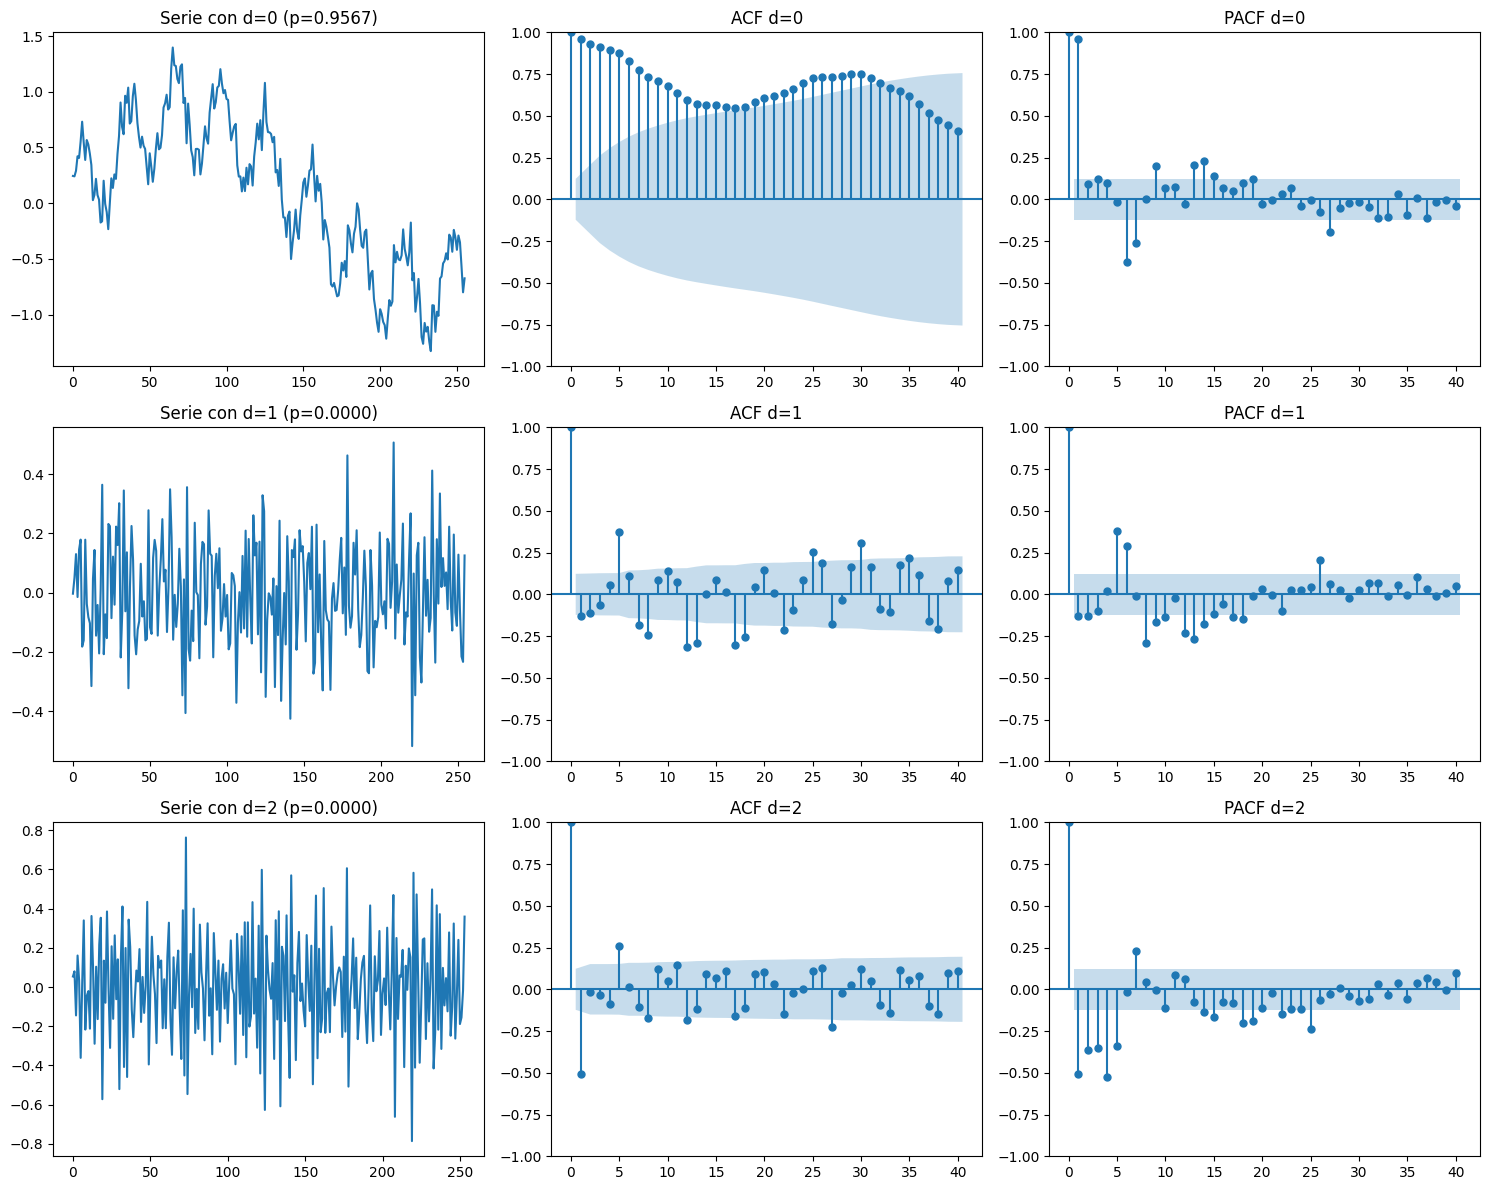

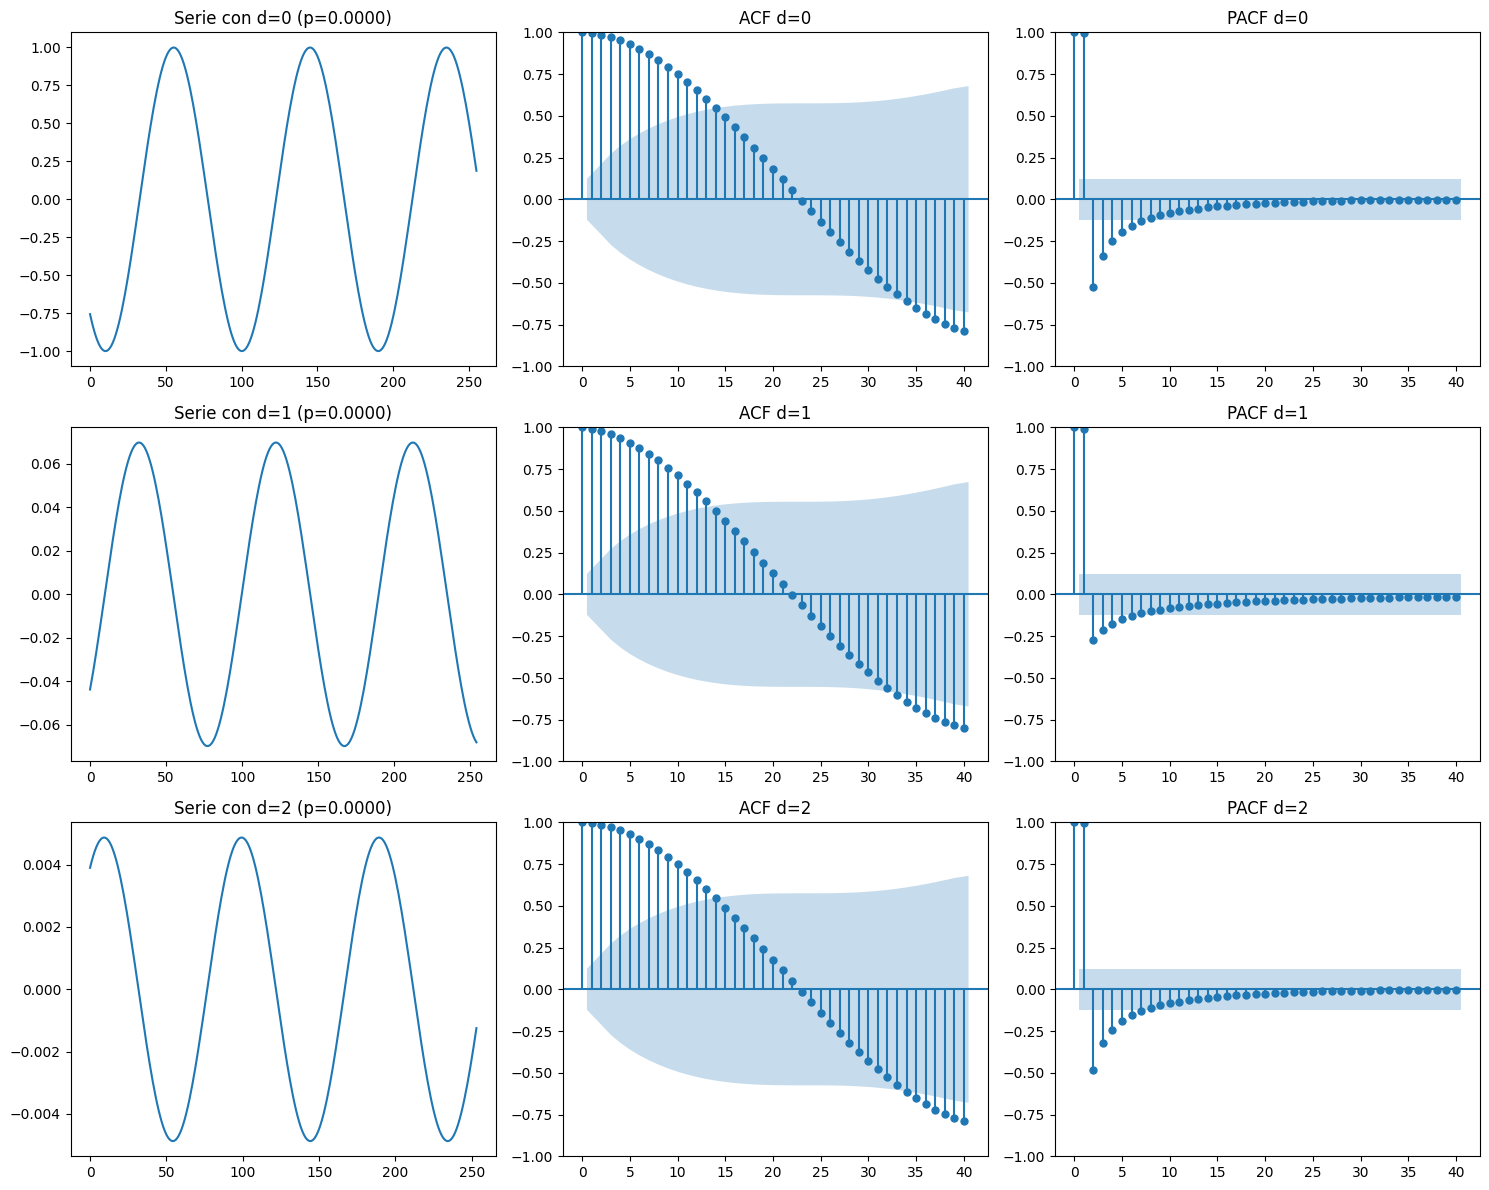

In [4]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

def analyze_sine_differentiation(y_train):
    if isinstance(y_train, np.ndarray):
        y_train = pd.Series(y_train)
    results = []
    y_diff = y_train.copy()
    
    fig, axes = plt.subplots(3, 3, figsize=(15, 12))
    
    for d in range(3):
        current_data = y_diff.dropna()
        adf_res = adfuller(current_data)
        p_val = adf_res[1]
        is_stationary = p_val < 0.05
        
        results.append({'d': d, 'p-value': p_val, 'stationary': is_stationary})
        
        # Plot Serie
        axes[d, 0].plot(current_data.values)
        axes[d, 0].set_title(f"Serie con d={d} (p={p_val:.4f})")
        
        # Plot ACF
        plot_acf(current_data, ax=axes[d, 1], lags=40)
        axes[d, 1].set_title(f"ACF d={d}")
        
        # Plot PACF
        plot_pacf(current_data, ax=axes[d, 2], lags=40)
        axes[d, 2].set_title(f"PACF d={d}")
        
        y_diff = y_diff.diff()

    plt.tight_layout()
    plt.show()
    

y_train = sine_dataset(length=256)
analyze_sine_differentiation(y_train)

y_train = sine_dataset(length=256, EASY_DATASET=True)
analyze_sine_differentiation(y_train)

[*********************100%***********************]  1 of 1 completed


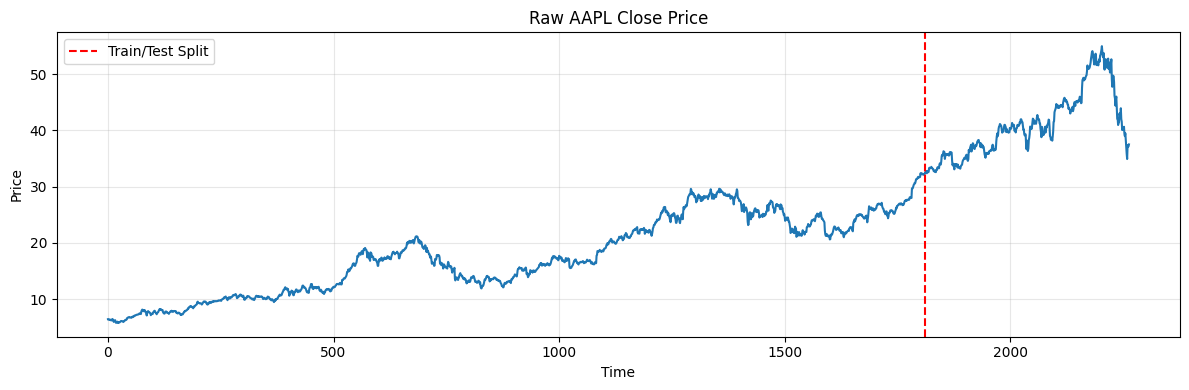

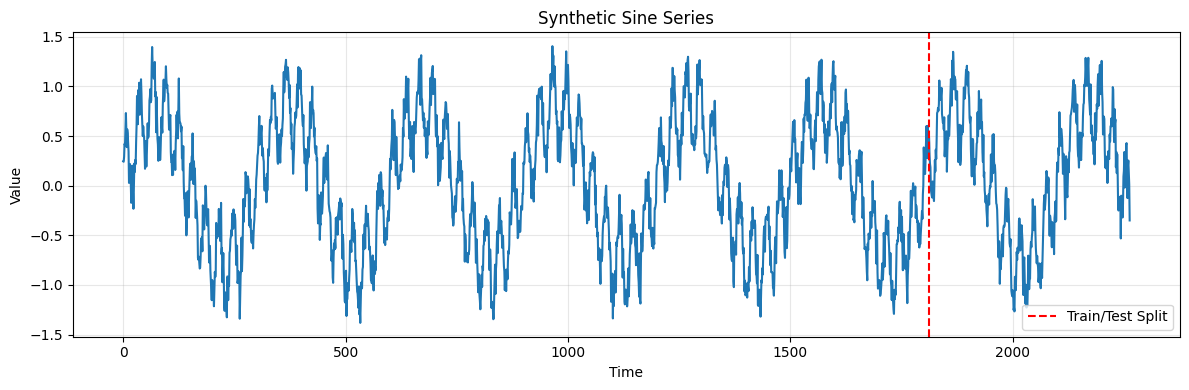

In [5]:
# APL plot
df = yf.download("AAPL", start="2010-01-01", end="2019-01-01")
real_series = df["Close"].dropna().values
split_idx = int(0.8 * len(real_series))

plt.figure(figsize=(12, 4))
plt.plot(real_series)
plt.axvline(x=split_idx, color='red', linestyle='--', linewidth=1.5, label='Train/Test Split')
plt.title("Raw AAPL Close Price")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# Sine plot
synthetic_series = sine_dataset(length=2264)

plt.figure(figsize=(12, 4))
plt.plot(synthetic_series)
plt.axvline(x=split_idx, color='red', linestyle='--', linewidth=1.5, label='Train/Test Split')
plt.title("Synthetic Sine Series")
plt.xlabel("Time")
plt.ylabel("Value")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Last update

In [4]:
import json
from datetime import datetime

def update_experiment_database(all_results, real_data=True, base_filename="metrics_db"):
    """
    Load json and add results.
    all_results: Dict
    """
    date_str = datetime.now().strftime("%Y-%m-%d")
    if real_data:
        filename = f"{base_filename}_{date_str}.json"
    else:
        filename = f"synth_{base_filename}_{date_str}.json"

    existing_data = {}
    if os.path.exists(filename):
        with open(filename, "r") as f:
            try:
                existing_data = json.load(f)
            except json.JSONDecodeError:
                existing_data = {}

    existing_data.update(all_results)

    with open(filename, "w") as f:
        json.dump(existing_data, f, indent=4)
    
    print(f"\n[INFO] Database updated in {filename}")

In [5]:
# Define hyperparameters 
context_length = [256]
horizon_length = [1, 4, 8, 16, 24, 32]
horizon_length = [1, 4, 8]
freq_type = 0
is_real_data = [False]


for val in is_real_data:
    results = {
        "freq_type": freq_type,
        "is_real_data": val,
        "experiments": []
    }

    for c in context_length:
        for h in horizon_length:

            res = compare_performance(
                context_len=c,
                horizon_len=h,
                real_data=val,
                more_models=True,
                freq_type=freq_type
            )

            results["experiments"].append({
                "context_length": c,
                "horizon": h,
                "metrics": res
            })

    date_str = datetime.now().strftime("%Y-%m-%d")
    if val:
        file_name = f"metrics_results_{date_str}.json"
    else:
        file_name = f"synth_metrics_results_{date_str}.json"

    with open(file_name, "w") as f:
        json.dump(results, f, indent=4)

Generating Synthetic Sine Dataset...
Created datasets:
- Training samples: 1555
- Test samples: 197
- Using frequency type: 0

Zero-Shot (Pre-trained) Evaluation


Fetching 5 files: 100%|██████████| 5/5 [00:00<?, ?it/s]


Zero-Shot RMSE: 0.4716

Fine-Tuning Process


Fetching 5 files: 100%|██████████| 5/5 [00:00<?, ?it/s]


Training...

Fine-Tuned Evaluation
Fine-Tuned RMSE: 0.1129

Performance Comparison (RMSE)
Zero-Shot (No Finetuning) RMSE: 0.4716
Fine-Tuned RMSE: 0.1129
Fine-tuning improved performance by: 76.06%

Evaluating additional models (ARIMA, LSTM, Persistence)...
ARIMA model selected:
Order (p,d,q): (3, 1, 2)

Global Metrics & Time Comparison:
TimesFM ZeroShot: {'RMSE': np.float64(0.4716346115360977), 'Inference_Time': 12.471024990081787}
TimesFM Finetuned: {'RMSE': np.float64(0.11292691459894211), 'Training_Time': 2112.1405804157257, 'Inference_Time': 11.894858598709106}
ARIMA: {'RMSE': 0.15803596484761062, 'Inference_Time': 64.18285298347473}
Persistence: {'RMSE': 0.1873014271259308, 'Inference_Time': 0.015613555908203125}
LSTM Multi Output: {'RMSE': 0.15143877267837524, 'Training_Time': 86.4392876625061, 'Inference_Time': 0.0796976089477539}
LSTM Multi Model: {'RMSE': 0.1530766636133194, 'Training_Time': 195.27118349075317, 'Inference_Time': 0.053536176681518555}
LSTM AR: {'RMSE': 0.148745

...

Training...

Fine-Tuned Evaluation
Fine-Tuned RMSE: 0.1105

Performance Comparison (RMSE)
Zero-Shot (No Finetuning) RMSE: 0.5528
Fine-Tuned RMSE: 0.1105
Fine-tuning improved performance by: 80.02%

Evaluating additional models (ARIMA, LSTM, Persistence)...
ARIMA model selected:
Order (p,d,q): (3, 1, 2)

Global Metrics & Time Comparison:
TimesFM ZeroShot: {'RMSE': np.float64(0.5528321776283928), 'Inference_Time': 14.203955173492432}
TimesFM Finetuned: {'RMSE': np.float64(0.11045258215864123), 'Training_Time': 1931.4686827659607, 'Inference_Time': 11.699445009231567}
ARIMA: {'RMSE': 0.2761551155735942, 'Inference_Time': 55.80401039123535}
Persistence: {'RMSE': 0.29153573513031006, 'Inference_Time': 0.007003307342529297}
LSTM Multi Output: {'RMSE': 0.11694195121526718, 'Training_Time': 247.88058876991272, 'Inference_Time': 0.06850695610046387}
LSTM Multi Model: {'RMSE': 0.13349993526935577, 'Training_Time': 289.4166965484619, 'Inference_Time': 0.1520838737487793}
LSTM AR: {'RMSE': 0.12958

Fetching 5 files: 100%|██████████| 5/5 [00:00<?, ?it/s]


Zero-Shot RMSE: 0.5047

Fine-Tuning Process


Fetching 5 files: 100%|██████████| 5/5 [00:00<?, ?it/s]


Training...

Fine-Tuned Evaluation
Fine-Tuned RMSE: 0.1417

Performance Comparison (RMSE)
Zero-Shot (No Finetuning) RMSE: 0.5047
Fine-Tuned RMSE: 0.1417
Fine-tuning improved performance by: 71.93%

Evaluating additional models (ARIMA, LSTM, Persistence)...
ARIMA model selected:
Order (p,d,q): (3, 1, 2)

Global Metrics & Time Comparison:
TimesFM ZeroShot: {'RMSE': np.float64(0.5046898782259792), 'Inference_Time': 9.265178680419922}
TimesFM Finetuned: {'RMSE': np.float64(0.14166541318112244), 'Training_Time': 2087.511293888092, 'Inference_Time': 11.786997318267822}
ARIMA: {'RMSE': 0.452865721113042, 'Inference_Time': 60.06954383850098}
Persistence: {'RMSE': 0.4728253185749054, 'Inference_Time': 0.019438743591308594}
LSTM Multi Output: {'RMSE': 0.13068684935569763, 'Training_Time': 128.70349311828613, 'Inference_Time': 0.04459404945373535}
LSTM Multi Model: {'RMSE': 0.1404637098312378, 'Training_Time': 781.327849149704, 'Inference_Time': 0.38842344284057617}
LSTM AR: {'RMSE': 0.1152058765

### Plot Real Data

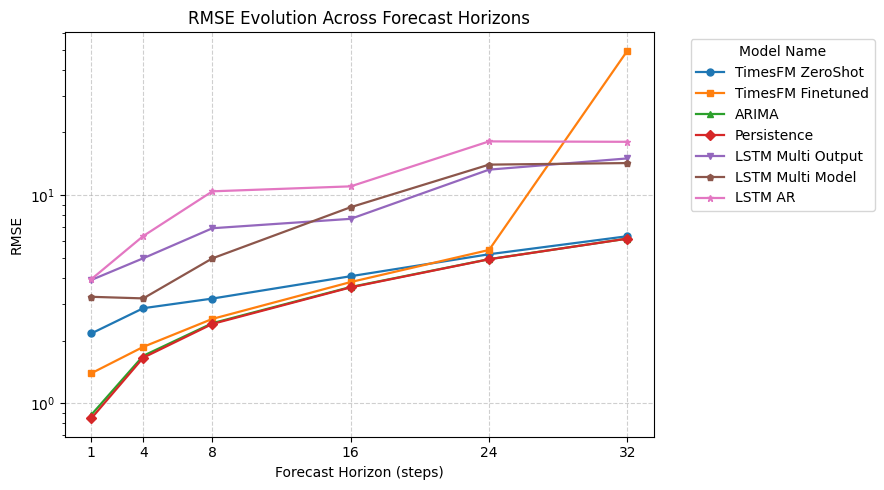

In [8]:
with open("metrics_results_2026-02-02.json", "r") as f:
    data = json.load(f)

all_results = data["experiments"]
filtered_results = [
    exp for exp in all_results
    if exp["context_length"] == 256
]

session_results = {}

for exp in filtered_results:
    h = exp["horizon"]
    session_results[f"horizon_{h}"] = exp["metrics"]

horizon_keys = list(session_results.keys())
horizons = [int(x.split('_')[-1]) for x in horizon_keys]
models = list(session_results[horizon_keys[0]].keys())

rmse_evolution = {model: [session_results[h_key][model]['RMSE'] for h_key in horizon_keys] for model in models}

plt.figure(figsize=(9, 5))
markers = ['o', 's', '^', 'D', 'v', 'p', '*']

for i, model in enumerate(models):
    plt.plot(horizons, rmse_evolution[model], 
             marker=markers[i % len(markers)], 
             label=model, 
             linewidth=1.6, 
             markersize=5)

plt.title('RMSE Evolution Across Forecast Horizons')
plt.xlabel('Forecast Horizon (steps)')
plt.ylabel('RMSE')
plt.yscale('log')
plt.xticks(horizons)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Model Name', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.savefig('rmse_evolution.png')
plt.show()

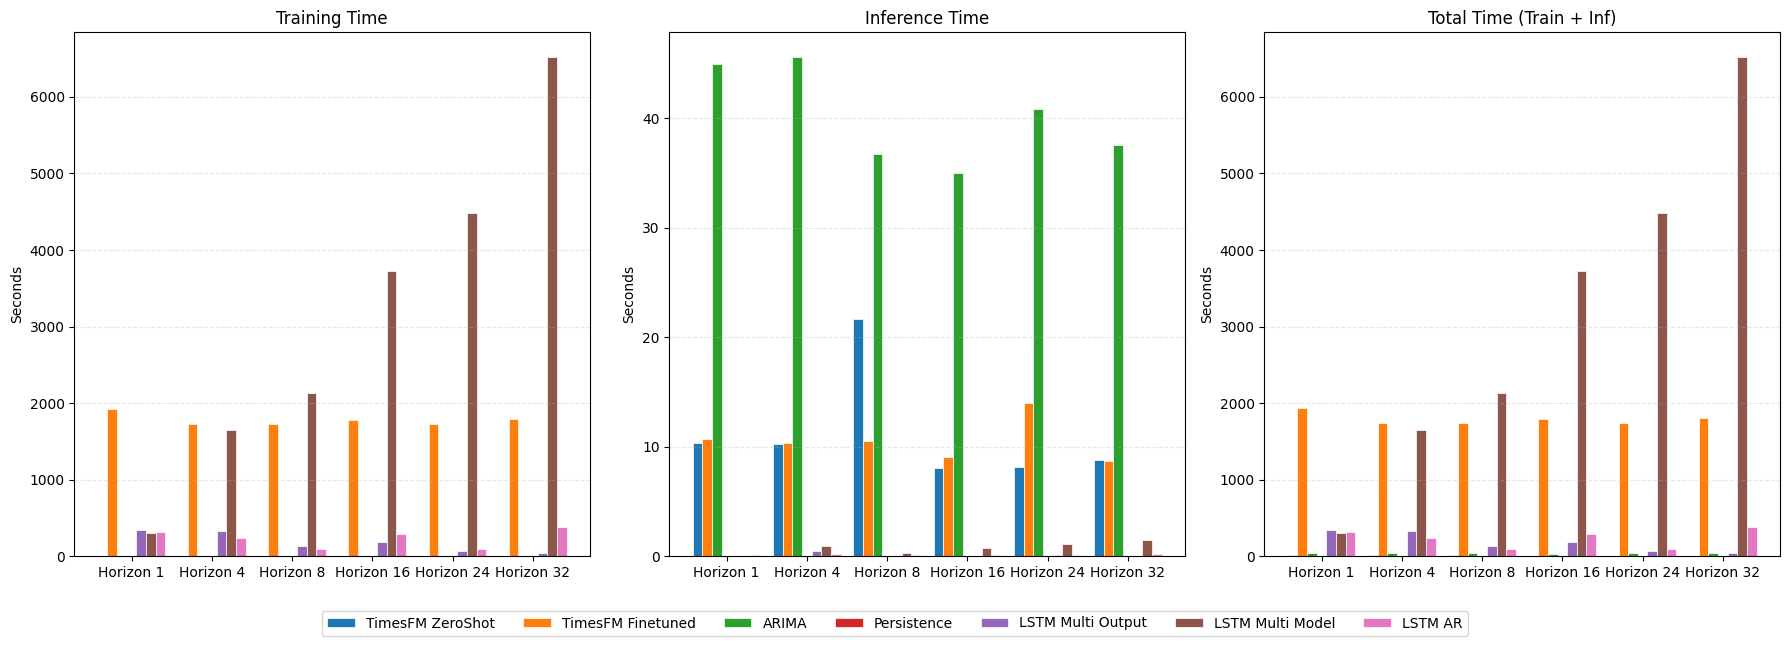

In [9]:
metrics = {
    'Training Time': {m: [session_results[h][m].get('Training_Time', 0) for h in horizon_keys] for m in models},
    'Inference Time': {m: [session_results[h][m].get('Inference_Time', 0) for h in horizon_keys] for m in models},
}
metrics['Total Time'] = {m: [metrics['Training Time'][m][i] + metrics['Inference Time'][m][i] 
                            for i in range(len(horizons))] for m in models}


fig, axes = plt.subplots(1, 3, figsize=(18, 6))
x = np.arange(len(horizons))  # Label locations
width = 0.12  # Width of each individual bar

def render_bars(ax, metric_data, title):
    for i, model in enumerate(models):
        # Calculate position for each model's bar within the group
        pos = x + (i - len(models)/2) * width + width/2
        ax.bar(pos, metric_data[model], width, label=model, edgecolor='white', linewidth=0.5)
    
    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels([f'Horizon {h}' for h in horizons])
    ax.set_ylabel('Seconds')
    ax.grid(axis='y', linestyle='--', alpha=0.3)
    # ax.set_yscale('log')


render_bars(axes[0], metrics['Training Time'], 'Training Time')
render_bars(axes[1], metrics['Inference Time'], 'Inference Time')
render_bars(axes[2], metrics['Total Time'], 'Total Time (Train + Inf)')

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.08), 
           ncol=len(models))

plt.tight_layout()
plt.show()

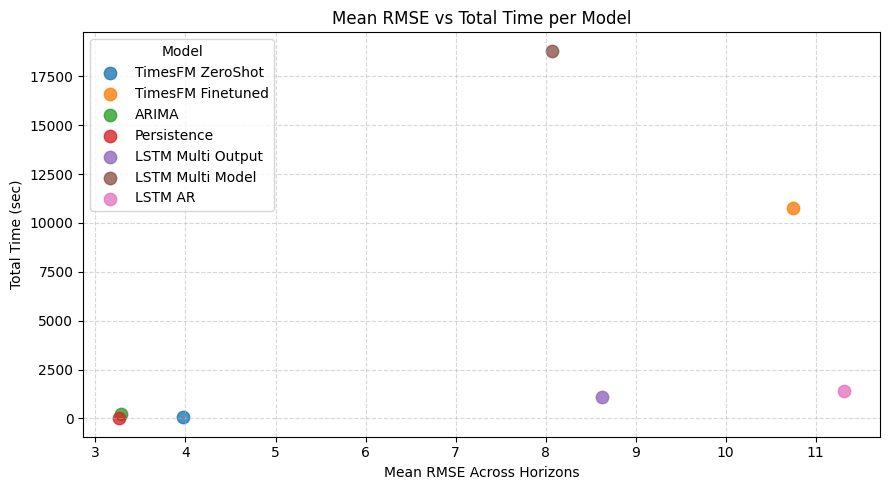

In [10]:
# Load metrics file
with open("metrics_results_2026-02-02.json", "r") as f:
    data = json.load(f)

all_results = data["experiments"]
filtered_results = [exp for exp in all_results if exp["context_length"] == 256]

session_results = {}
for exp in filtered_results:
    h = exp["horizon"]
    session_results[f"horizon_{h}"] = exp["metrics"]

horizon_keys = list(session_results.keys())
models = list(session_results[horizon_keys[0]].keys())
horizons = [int(x.split('_')[-1]) for x in horizon_keys]

# Calculate mean RMSE per model
rmse_evolution = {model: [session_results[h_key][model]['RMSE'] for h_key in horizon_keys] for model in models}
rmse_mean = {model: np.mean(rmse_evolution[model]) for model in models}

# Calculate total time per model across horizons
metrics = {
    'Training Time': {m: [session_results[h][m].get('Training_Time', 0) for h in horizon_keys] for m in models},
    'Inference Time': {m: [session_results[h][m].get('Inference_Time', 0) for h in horizon_keys] for m in models},
}
total_time = {m: np.sum([metrics['Training Time'][m][i] + metrics['Inference Time'][m][i] 
                         for i in range(len(horizons))]) for m in models}

# Plot
plt.figure(figsize=(9, 5))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2']
for i, model in enumerate(models):
    plt.scatter(rmse_mean[model], total_time[model], color=colors[i % len(colors)], s=80, label=model, alpha=0.8)

# for model in models:
#     plt.text(rmse_mean[model]*1.01, total_time[model]*1.01, model, fontsize=9)

plt.xlabel('Mean RMSE Across Horizons')
plt.ylabel('Total Time (sec)')
plt.title('Mean RMSE vs Total Time per Model')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Model')
plt.tight_layout()
plt.show()


### Plot Synthetic Data

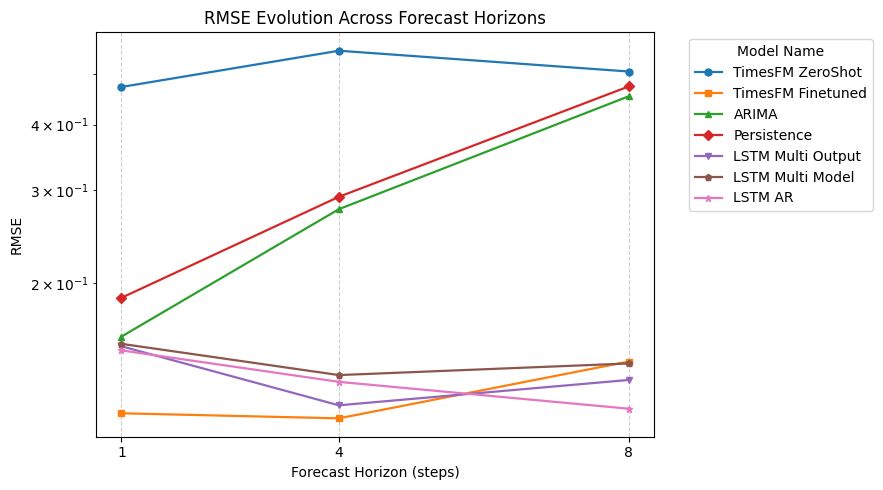

In [11]:
with open("synth_metrics_results_2026-02-02.json", "r") as f:
    data = json.load(f)

all_results = data["experiments"]
filtered_results = [
    exp for exp in all_results
    if exp["context_length"] == 256
]

session_results = {}

for exp in filtered_results:
    h = exp["horizon"]
    session_results[f"horizon_{h}"] = exp["metrics"]

horizon_keys = list(session_results.keys())
horizons = [int(x.split('_')[-1]) for x in horizon_keys]
models = list(session_results[horizon_keys[0]].keys())

rmse_evolution = {model: [session_results[h_key][model]['RMSE'] for h_key in horizon_keys] for model in models}

plt.figure(figsize=(9, 5))
markers = ['o', 's', '^', 'D', 'v', 'p', '*']

for i, model in enumerate(models):
    plt.plot(horizons, rmse_evolution[model], 
             marker=markers[i % len(markers)], 
             label=model, 
             linewidth=1.6, 
             markersize=5)

plt.title('RMSE Evolution Across Forecast Horizons')
plt.xlabel('Forecast Horizon (steps)')
plt.ylabel('RMSE')
plt.yscale('log')
plt.xticks(horizons)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Model Name', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.savefig('rmse_evolution.png')
plt.show()

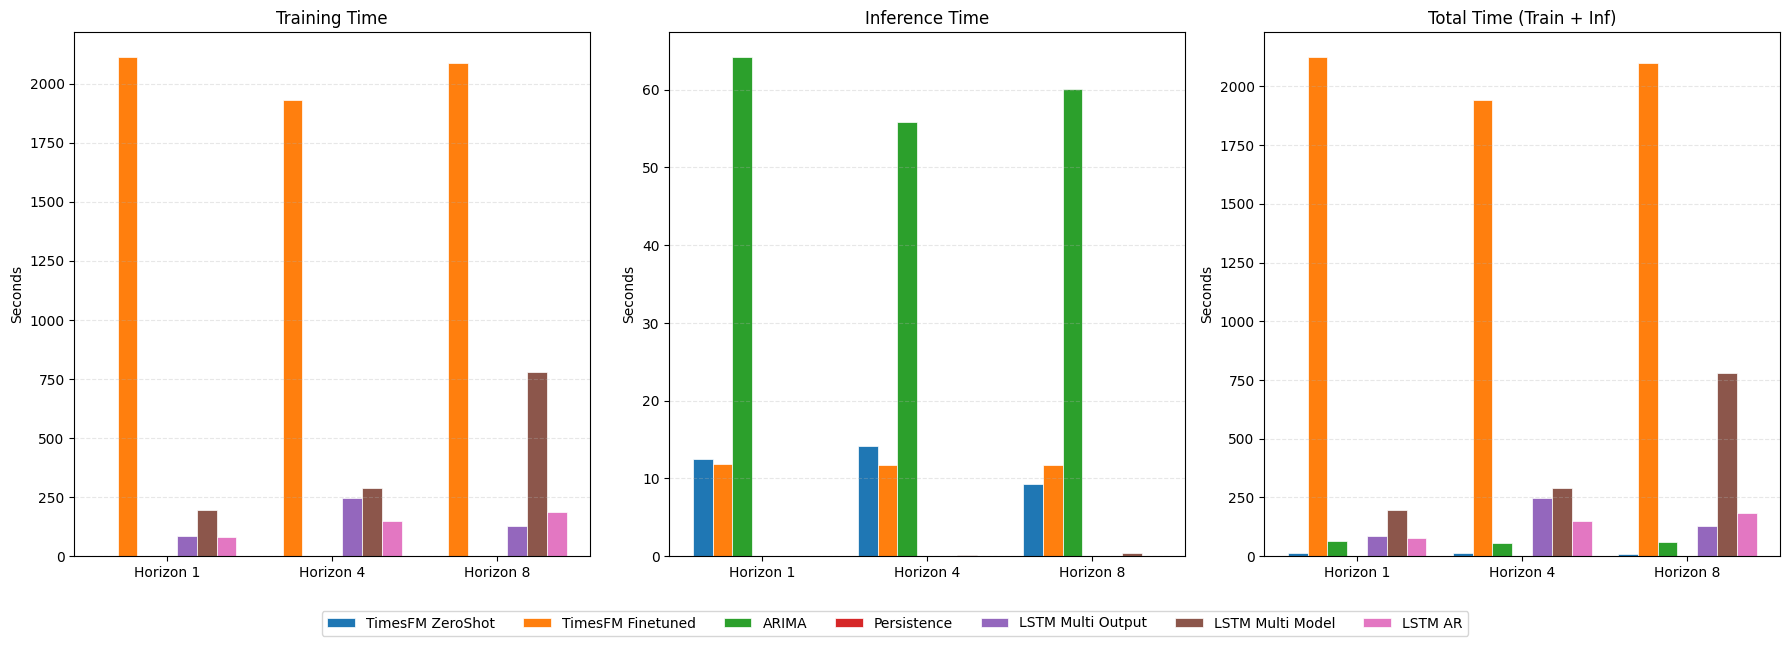

In [12]:
metrics = {
    'Training Time': {m: [session_results[h][m].get('Training_Time', 0) for h in horizon_keys] for m in models},
    'Inference Time': {m: [session_results[h][m].get('Inference_Time', 0) for h in horizon_keys] for m in models},
}
metrics['Total Time'] = {m: [metrics['Training Time'][m][i] + metrics['Inference Time'][m][i] 
                            for i in range(len(horizons))] for m in models}


fig, axes = plt.subplots(1, 3, figsize=(18, 6))
x = np.arange(len(horizons))  # Label locations
width = 0.12  # Width of each individual bar

def render_bars(ax, metric_data, title):
    for i, model in enumerate(models):
        # Calculate position for each model's bar within the group
        pos = x + (i - len(models)/2) * width + width/2
        ax.bar(pos, metric_data[model], width, label=model, edgecolor='white', linewidth=0.5)
    
    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels([f'Horizon {h}' for h in horizons])
    ax.set_ylabel('Seconds')
    ax.grid(axis='y', linestyle='--', alpha=0.3)
    # ax.set_yscale('log')


render_bars(axes[0], metrics['Training Time'], 'Training Time')
render_bars(axes[1], metrics['Inference Time'], 'Inference Time')
render_bars(axes[2], metrics['Total Time'], 'Total Time (Train + Inf)')

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.08), 
           ncol=len(models))

plt.tight_layout()
plt.show()

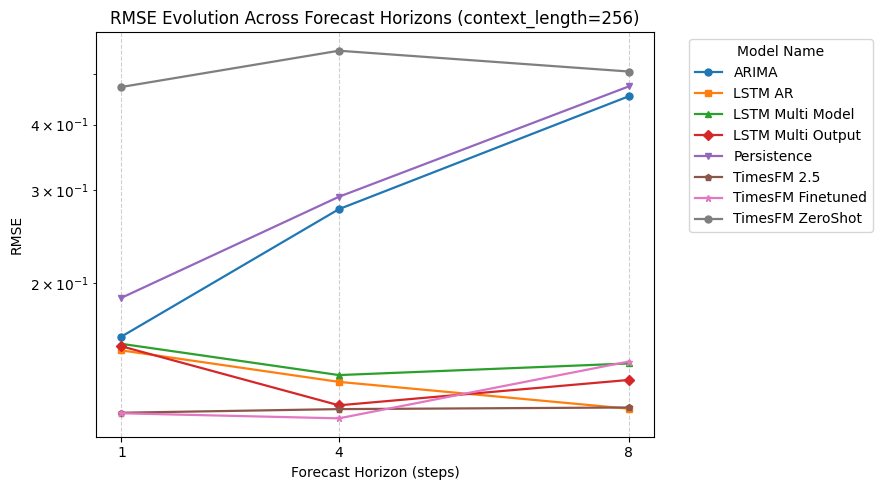

In [24]:
import math

with open("synth_metrics_results_2026-02-02.json", "r") as f:
    data1 = json.load(f)
with open("synth_timesfm2_5_results.json", "r") as f:
    data2 = json.load(f)

filtered_data1 = [exp for exp in data1['experiments'] if exp['context_length'] == 256]
filtered_data2 = [exp for exp in data2['experiments'] if exp['context_length'] == 256]


session_results = {}

for exp in filtered_data1:
    h = exp['horizon']
    session_results[f"horizon_{h}"] = exp['metrics'].copy()

for exp in filtered_data2:
    h = exp['horizon']
    if f"horizon_{h}" not in session_results:
        session_results[f"horizon_{h}"] = {}
    session_results[f"horizon_{h}"]['TimesFM 2.5'] = exp['metrics']['rmse']


horizon_keys = sorted(session_results.keys(), key=lambda x: int(x.split('_')[-1]))
horizons = [int(x.split('_')[-1]) for x in horizon_keys]

all_models = set()
for h_key in horizon_keys:
    all_models.update(session_results[h_key].keys())
models = sorted(list(all_models))

valid_horizon_keys = [
    h_key for h_key in session_results.keys()
    if all(model in session_results[h_key] for model in models)
]
valid_horizon_keys = sorted(valid_horizon_keys, key=lambda x: int(x.split('_')[-1]))
horizons = [int(x.split('_')[-1]) for x in valid_horizon_keys]

# RMSE evolution
rmse_evolution = {}
for model in models:
    rmse_list = []
    for h_key in valid_horizon_keys:
        val = session_results[h_key][model]
        if isinstance(val, dict) and 'RMSE' in val:
            rmse_list.append(val['RMSE'])
        else:
            rmse_list.append(val)  # float (TimesFM 2.5)
    rmse_evolution[model] = rmse_list

# Plot
plt.figure(figsize=(9, 5))
markers = ['o', 's', '^', 'D', 'v', 'p', '*']

for i, model in enumerate(models):
    plt.plot(horizons, rmse_evolution[model],
             marker=markers[i % len(markers)],
             label=model,
             linewidth=1.6,
             markersize=5)

plt.title('RMSE Evolution Across Forecast Horizons (context_length=256)')
plt.xlabel('Forecast Horizon (steps)')
plt.ylabel('RMSE')
plt.yscale('log')
plt.xticks(horizons)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Model Name', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

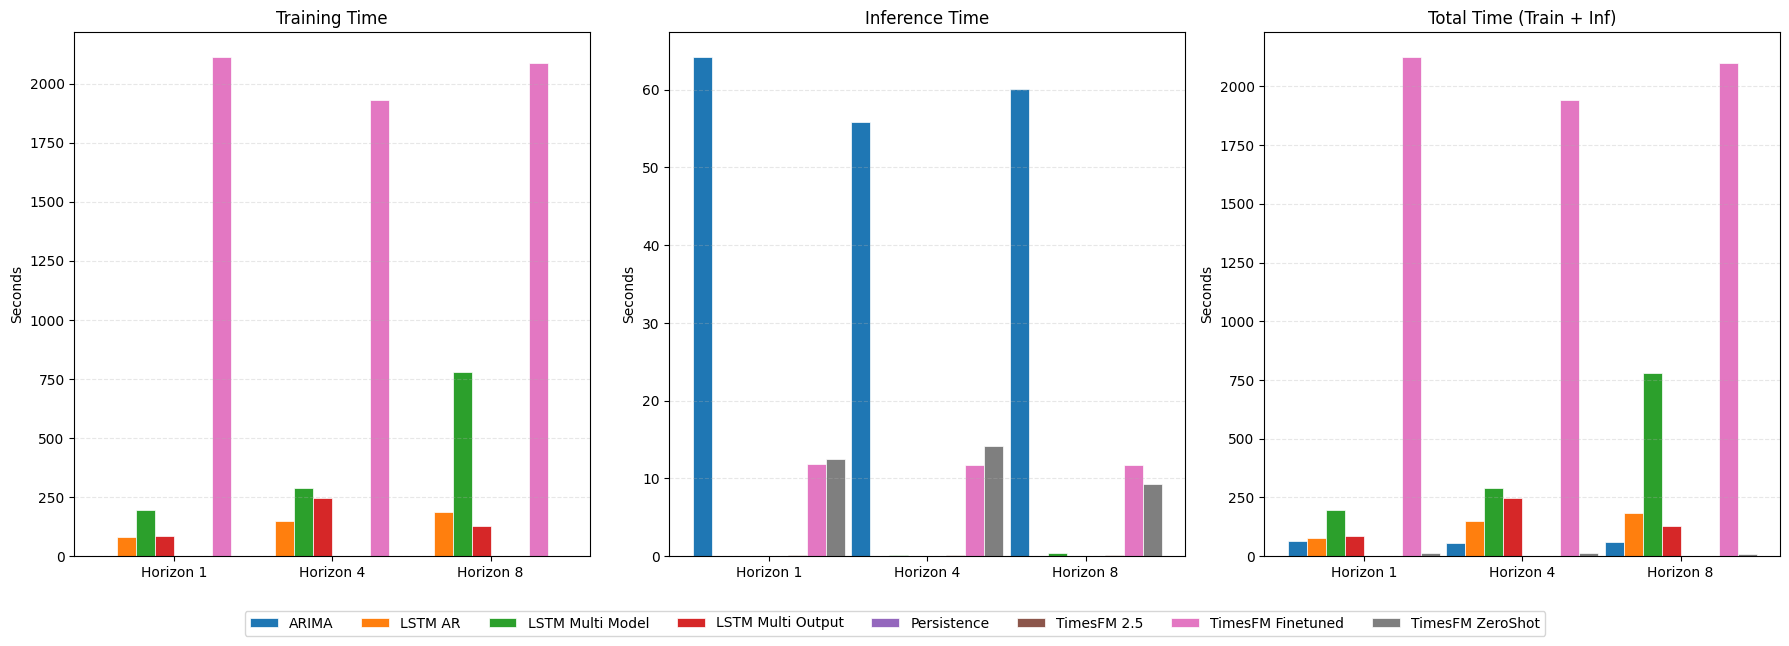

In [25]:
metrics = {'Training Time': {}, 'Inference Time': {}}

for m in models:
    train_times = []
    inf_times = []
    for h in valid_horizon_keys:
        val = session_results[h][m]
        if isinstance(val, dict):
            train_times.append(val.get('Training_Time', 0))
            inf_times.append(val.get('Inference_Time', 0))
        else:  # float (TimesFM 2.5)
            train_times.append(0)
            inf_times.append(val)
    metrics['Training Time'][m] = train_times
    metrics['Inference Time'][m] = inf_times

# Total Time = Training + Inference
metrics['Total Time'] = {
    m: [metrics['Training Time'][m][i] + metrics['Inference Time'][m][i] for i in range(len(valid_horizon_keys))]
    for m in models
}


fig, axes = plt.subplots(1, 3, figsize=(18, 6))
x = np.arange(len(valid_horizon_keys))
width = 0.12 

# Dibujar barras
render_bars(axes[0], metrics['Training Time'], 'Training Time')
render_bars(axes[1], metrics['Inference Time'], 'Inference Time')
render_bars(axes[2], metrics['Total Time'], 'Total Time (Train + Inf)')

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.08), ncol=len(models))

plt.tight_layout()
plt.show()

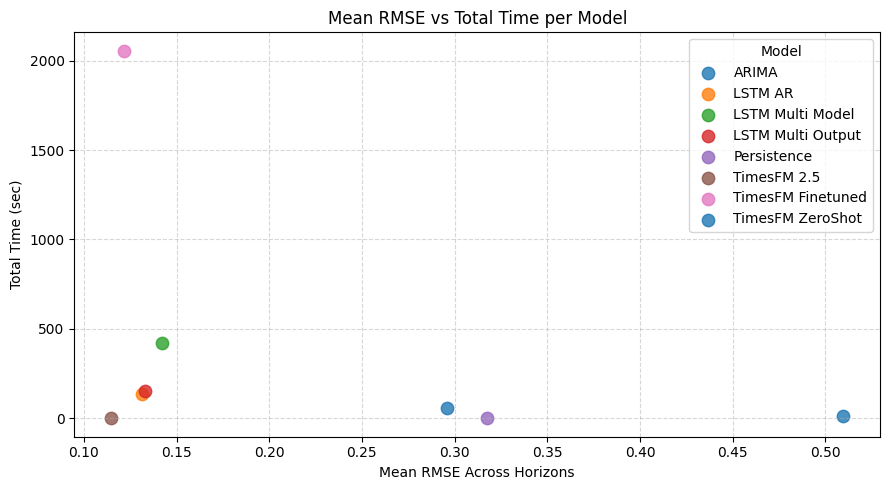

In [26]:
rmse_mean = {}
total_time = {}

for m in models:
    rmse_list = []
    t_list = []
    for h in valid_horizon_keys:
        val = session_results[h][m]
        if isinstance(val, dict):
            rmse_list.append(val['RMSE'])
            t_list.append(val.get('Training_Time', 0) + val.get('Inference_Time', 0))
        else:  # TimesFM 2.5
            rmse_list.append(val)
            t_list.append(val)  # solo inference_time
    rmse_mean[m] = np.mean(rmse_list)
    total_time[m] = np.mean(t_list)

# Scatter plot
plt.figure(figsize=(9, 5))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2']

for i, model in enumerate(models):
    plt.scatter(rmse_mean[model], total_time[model],
                color=colors[i % len(colors)], s=80, label=model, alpha=0.8)

plt.xlabel('Mean RMSE Across Horizons')
plt.ylabel('Total Time (sec)')
plt.title('Mean RMSE vs Total Time per Model')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Model')
plt.tight_layout()
plt.show()

In [ ]:
raise Exception("Execution paused. Check your data before continuing.")

### Observations

In [30]:
device = "cuda" if torch.cuda.is_available() else "cpu"
repo_id = "google/timesfm-2.5-200m-pytorch"
hparams = TimesFmHparams(
    backend=device,
    per_core_batch_size=32,
    horizon_len=128,
    num_layers=20,
    use_positional_embedding=False,
    context_len=192,
)
tfm = TimesFm(hparams=hparams,
                checkpoint=TimesFmCheckpoint(huggingface_repo_id=repo_id))

# cannot find model in hugging face folders 

Fetching 4 files: 100%|██████████| 4/4 [00:00<?, ?it/s]


FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\casas\\.cache\\huggingface\\hub\\models--google--timesfm-2.5-200m-pytorch\\snapshots\\1d952420fba87f3c6dee4f240de0f1a0fbc790e3\\torch_model.ckpt'